# YOLO + VLM Hands-on: Same Video, Different Questions

Change **one line**. Keep the video and visual evidence fixed. Observe how a new question changes the VLM answer.

```text
YOLO every frame -> Coordinator selects evidence -> VLM answers your question
```

## 1. Two clocks, one coordinator

| Layer | Rhythm | Controls |
|---|---|---|
| YOLO | every frame | visible objects and positions |
| Coordinator | selected moments | trigger and evidence |
| VLM | on demand | interpretation of that evidence |

You control the **question**. The application owns model loading, HTTP, timing, and rendering.

In [1]:
import importlib
import json
import os
import sys
from pathlib import Path


NOTEBOOK_DIR = Path.cwd().resolve()
BAKED_SEED = Path(os.environ.get(
    "ULTRALYTICS_WORKSHOP_SEED_DIR", "/opt/ultralytics-yolo26/seed"
)).resolve()
BAKED_MODELS = Path(os.environ.get(
    "ULTRALYTICS_BAKED_MODEL_DIR", "/opt/ultralytics-yolo26/models"
)).resolve()


def is_package_root(path: Path) -> bool:
    return (
        (path / "scripts/notebook_env.py").is_file()
        and (path / "src").is_dir()
        and (path / "data").is_dir()
    )


def find_package_root() -> Path:
    candidates = []
    for variable in ("ULTRALYTICS_YOLO26_ROOT", "OPENCV_AMD_END2END_ROOT"):
        if os.environ.get(variable):
            candidates.append(Path(os.environ[variable]).expanduser())
    candidates.extend([NOTEBOOK_DIR, *NOTEBOOK_DIR.parents])
    candidates.extend(Path(value) for value in sys.path if value)
    candidates.append(BAKED_SEED)

    visited = set()
    for origin in candidates:
        try:
            resolved = origin.resolve()
        except (OSError, RuntimeError):
            continue
        for candidate in (resolved, *resolved.parents):
            if candidate in visited:
                continue
            visited.add(candidate)
            if is_package_root(candidate):
                return candidate
    raise FileNotFoundError(
        "Cannot find the ultralytics_yolo26 sources from the current directory "
        f"({NOTEBOOK_DIR}) or immutable seed ({BAKED_SEED})."
    )


def map_baked_models(work_dir: Path, source_dir: Path) -> tuple[Path, str]:
    required = (
        "yolo26x.pt",
        "yolo26x.onnx",
        "Qwen3-VL-8B-Instruct-Q8_0.gguf",
        "mmproj-F16.gguf",
    )
    missing = [name for name in required if not (source_dir / name).is_file()]
    if missing:
        raise FileNotFoundError(
            f"Baked model directory is incomplete: {source_dir}; missing={missing}"
        )

    alias = work_dir / "models"
    if alias.is_symlink():
        if alias.resolve() != source_dir:
            alias.unlink()
            alias.symlink_to(source_dir, target_is_directory=True)
        return alias.resolve(), "symlink"
    if alias.exists():
        if alias.resolve() == source_dir:
            return source_dir, "existing mapping"
        local_missing = [name for name in required if not (alias / name).is_file()]
        if local_missing:
            raise RuntimeError(
                f"Cannot map baked models: {alias} is an existing real path and "
                f"does not contain the release model set (missing={local_missing}). "
                "Remove that mount/directory or set ULTRALYTICS_YOLO26_MODEL_DIR "
                "to a complete model set."
            )
        return alias.resolve(), "existing model directory"

    try:
        alias.symlink_to(source_dir, target_is_directory=True)
        return alias.resolve(), "symlink"
    except OSError as error:
        print(
            f"[bootstrap] Cannot create {alias} -> {source_dir}: {error}. "
            "Using the immutable model directory directly."
        )
        return source_dir, "direct fallback"


ROOT = find_package_root()
MODEL_DIR, MODEL_MAPPING = map_baked_models(NOTEBOOK_DIR, BAKED_MODELS)
OUTPUT_DIR = NOTEBOOK_DIR / "output" / "hands_on"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

os.environ["ULTRALYTICS_YOLO26_ROOT"] = str(ROOT)
os.environ["ULTRALYTICS_YOLO26_MODEL_DIR"] = str(MODEL_DIR)
os.environ["ULTRALYTICS_YOLO26_OUTPUT_DIR"] = str(OUTPUT_DIR)
os.environ["ULTRALYTICS_YOLO26_PIPELINE_DIR"] = str(
    NOTEBOOK_DIR / "output" / "pipeline"
)
os.environ["ULTRALYTICS_MIGRAPHX_CACHE_ROOT"] = str(
    MODEL_DIR / "ort-migraphx-cache"
)
os.environ.setdefault("HF_ENDPOINT", "https://hf-mirror.com")
for value in (str(ROOT), str(ROOT / "src")):
    if value not in sys.path:
        sys.path.insert(0, value)

from scripts import notebook_env as env
env = importlib.reload(env)
from IPython.display import Markdown, display
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from scripts.model_setup import ensure_models, model_status, wait_for_llamacpp
from scripts.notebook_helpers import capture_log, frame_at, show_bgr, show_bgr_grid, show_video, video_info
from scripts.validate_runtime import validate

delivery_mode = (
    "baked/offline verification"
    if os.environ.get("ULTRALYTICS_WORKSHOP_BUNDLE") == "baked"
    else "development fallback download"
)
from scripts.hands_on_prompt_lab import DEFAULT_QUESTION, PromptLab, compose_prompt
with capture_log(env.OUTPUT / "logs/environment.log", "Environment validation"):
    models = ensure_models(env.MODELS, progress=True)
    runtime = validate(require_models=True, require_vlm=True)
    wait_for_llamacpp(timeout=60, progress=False)
    lab = PromptLab.prepare(output_dir=env.OUTPUT)
display(Markdown(
    f"**Ready:** YOLO runs every frame; VLM answers at selected evidence windows. "
    f"GPU `{runtime['torch_gpu']}`; output `{env.OUTPUT}`."
))

Environment validation: complete (full log: /workspace/output/hands_on/logs/environment.log)


**Ready:** YOLO runs every frame; VLM answers at selected evidence windows. GPU `AMD Radeon PRO W7900D`; output `/workspace/output/hands_on`.

## 2. Freeze the evidence

The next comparison keeps the YOLO frame, three-frame storyboard, and evidence hash identical.

Before running: what is visible, and what remains uncertain?

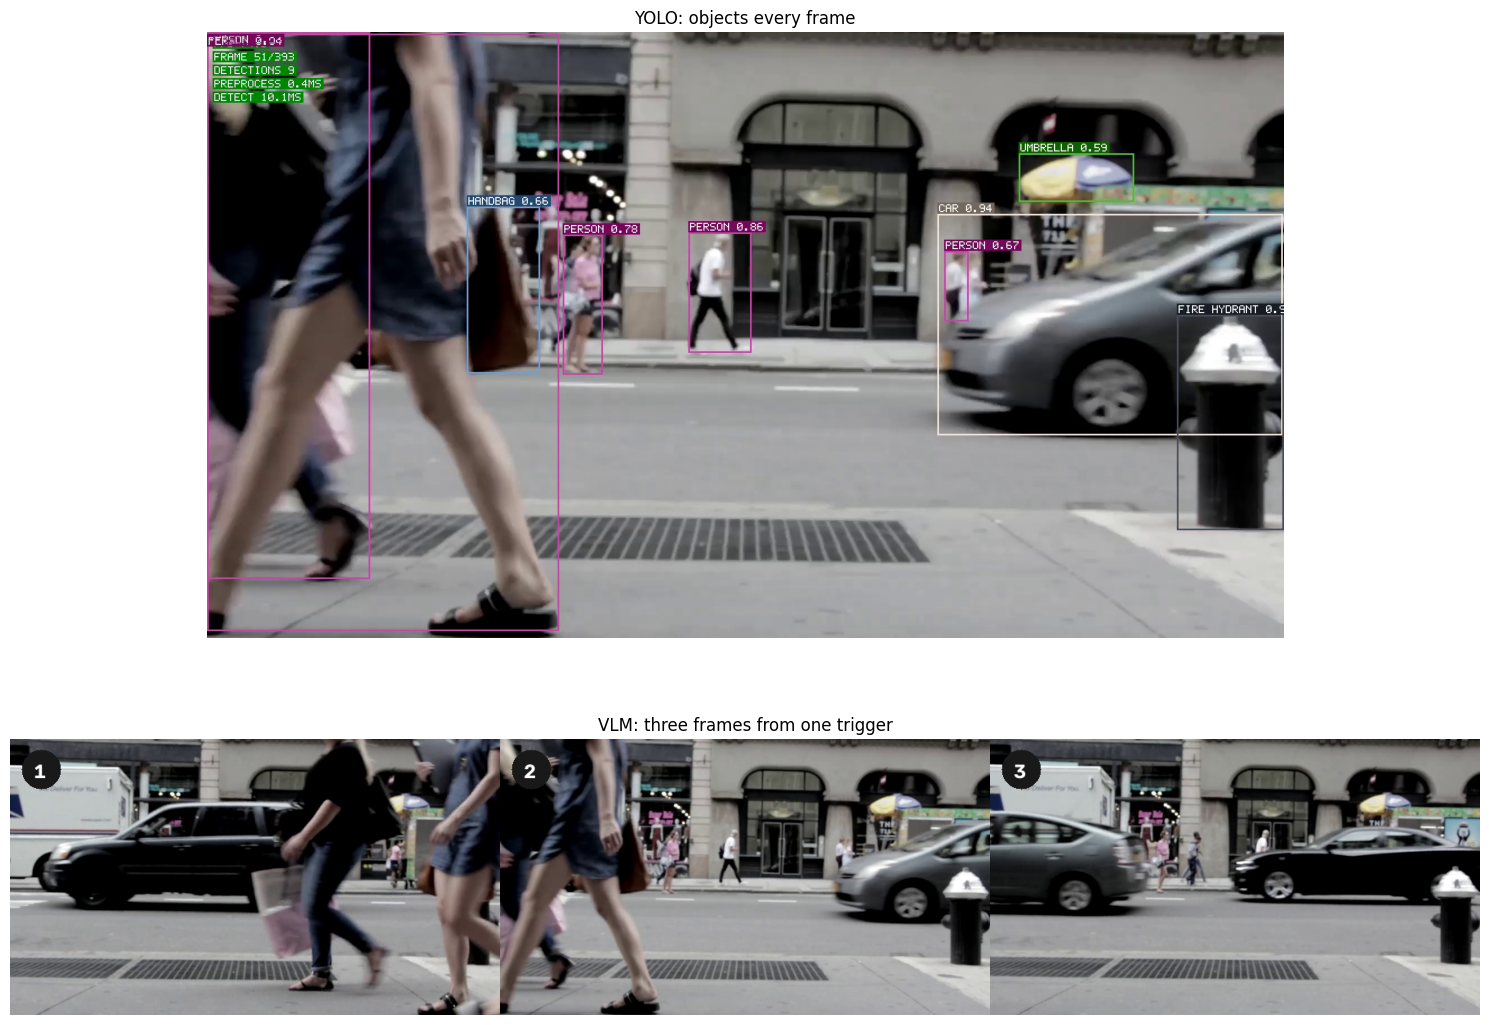

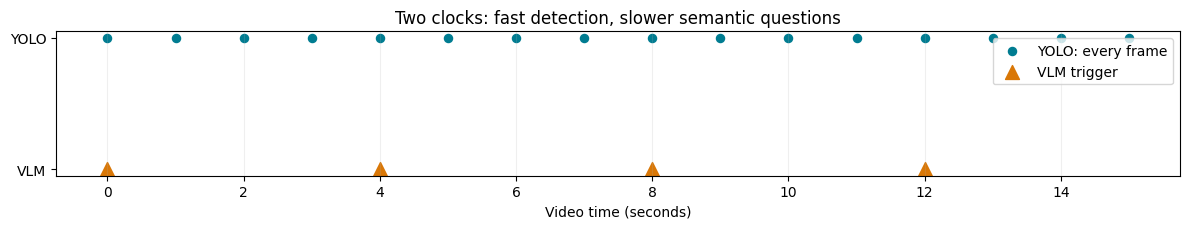

**Trigger window:** `0.0-4.0 s`  
**Evidence SHA:** `19a893a8155cb262...`

In [2]:
evidence = lab.evidence(0)
yolo_frame = frame_at(lab.yolo_video, evidence["sample_times"][1])
storyboard = cv2.imread(evidence["storyboard"])
assert storyboard is not None
show_bgr_grid(
    [yolo_frame, storyboard],
    ["YOLO: objects every frame", "VLM: three frames from one trigger"],
    columns=1,
    size=(15, 12),
)
figure, axis = plt.subplots(figsize=(12, 2.4))
axis.scatter(range(16), [1] * 16, color="#007c91", s=34, label="YOLO: every frame")
trigger_seconds = [0, 4, 8, 12]
axis.scatter(trigger_seconds, [0] * 4, color="#d97706", marker="^", s=100, label="VLM trigger")
axis.set_yticks([0, 1], ["VLM", "YOLO"])
axis.set_xlabel("Video time (seconds)")
axis.set_title("Two clocks: fast detection, slower semantic questions")
axis.legend(loc="upper right")
axis.grid(axis="x", alpha=0.2)
figure.tight_layout()
plt.show()
display(Markdown(
    f"**Trigger window:** `{evidence['start']:.1f}-{evidence['end']:.1f} s`  \n"
    f"**Evidence SHA:** `{evidence['sha256'][:16]}...`"
))

## 3. Your Prompt Card

The system keeps role, length, and grounding rules fixed. Change only the question.

Examples:

- `What is happening in this scene?`
- `What road-safety risks are visible?`
- `Describe this scene for someone who cannot see it.`

In [3]:
# EDIT ONLY THIS LINE
MY_QUESTION = "What road-safety risks are visible?"

display(Markdown(f"### Your question\n\n> {MY_QUESTION}"))

### Your question

> What road-safety risks are visible?

## 4. Predict before running

The evidence will not change. Which visible facts should your question emphasize?

In [4]:
with capture_log(env.OUTPUT / "logs/prompt_compare.log", "Prompt comparison"):
    comparison = lab.compare(MY_QUESTION)
assert comparison["evidence"]["sha256"] == evidence["sha256"]
display(Markdown(
    f"### Default question\n> {comparison['default']['question']}\n\n"
    f"**Answer:** {comparison['default']['answer']}\n\n"
    f"### Your question\n> {comparison['custom']['question']}\n\n"
    f"**Answer:** {comparison['custom']['answer']}\n\n"
    f"**Same evidence SHA:** `{comparison['evidence']['sha256'][:16]}...`"
))

Prompt comparison: complete (full log: /workspace/output/hands_on/logs/prompt_compare.log)


### Default question
> What is happening in this scene?

**Answer:** Pedestrians cross street as cars pass by in urban setting.

### Your question
> What road-safety risks are visible?

**Answer:** Pedestrians cross street while vehicles move nearby, risking collision.

**Same evidence SHA:** `19a893a8155cb262...`

## 5. Why did the answer change?

- Same evidence, different prompt -> different **focus**.
- Prompt controls the question and answer format.
- Prompt cannot add objects or events that are not visible.

Check relevance, visible grounding, and the one-sentence format.

In [5]:
with capture_log(env.OUTPUT / "logs/custom_timeline.log", "Four-trigger timeline"):
    custom_timeline = lab.run_timeline(
        MY_QUESTION,
        comparison=comparison,
        force=os.environ.get("RUN_CUSTOM_TIMELINE", "0") == "1",
    )
timeline_rows = [
    {
        "trigger": f"{segment['start']:.1f}-{segment['end']:.1f} s",
        "evidence": segment["evidence_sha256"][:12],
        "answer": segment["caption"],
    }
    for segment in custom_timeline["segments"]
]
display(pd.DataFrame(timeline_rows))

Four-trigger timeline: complete (full log: /workspace/output/hands_on/logs/custom_timeline.log)


,trigger,evidence,answer
0,0.0-4.0 s,19a893a8155c,Pedestrians cross street while vehicles move n...
1,4.0-8.0 s,4cff18b4afc6,Pedestrian crossing street with moving vehicle...
2,8.0-12.0 s,8f57dd7c3750,Pedestrians and cyclist cross street near vehi...
3,12.0-15.7 s,5acf562814c3,"Pedestrians crossing street near moving truck,..."


## 6. Same YOLO video, different semantic view

YOLO boxes stay fixed. Trigger selects the four evidence windows; your question changes the semantic timeline.

In [6]:
videos = lab.video_paths()
show_video(videos["baseline"], "Baseline: general scene summary")
show_video(videos["custom"], f"Custom: {MY_QUESTION}")
assert video_info(videos["baseline"])["frames"] == 393
assert video_info(videos["custom"])["frames"] == 393

## 7. What you control

| Control | Meaning |
|---|---|
| Prompt | what the VLM focuses on |
| Trigger | when the coordinator asks |
| Evidence | which frames the VLM receives |
| YOLO boxes | fixed model facts in this exercise |

A prompt changes interpretation, not the underlying video.

In [7]:
conclusion = "The question changed the focus while the visual evidence and YOLO detections stayed fixed."
submission_path = lab.save_submission(
    MY_QUESTION,
    comparison,
    custom_timeline,
    conclusion,
)
submission = json.loads(submission_path.read_text())
display(Markdown(
    f"**Saved:** `{submission_path}`  \n"
    f"**Focus changed:** `{submission['automatic_checks']['focus_changed']}`  \n"
    f"**Within 20 words:** `{submission['automatic_checks']['format_within_20_words']}`"
))

**Saved:** `/workspace/output/hands_on/submission.json`  
**Focus changed:** `True`  
**Within 20 words:** `True`

## 8. Takeaways

1. **YOLO sees objects every frame.**
2. **The coordinator decides when and what evidence reaches VLM.**
3. **Your prompt decides what the VLM focuses on.**

You write the question; the application owns the complex model and pipeline work.